# Random Forest Model

This notebook trains a Random Forest model for cancellation prediction.

## Metrics Targets
- **F2-Score**: ≥ 0.68
- **Recall**: ≥ 70%
- **Precision**: ≥ 60%

In [ ]:
import sys
import os
import pickle
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    f1_score, fbeta_score, precision_score, recall_score,
    roc_auc_score
)

sys.path.append(os.path.abspath(".."))
from src.evaluation import evaluate_model, find_optimal_threshold, plot_evaluation, METRIC_TARGETS

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load processed data
data_dir = "../data/silver"

X_train = pd.read_parquet(os.path.join(data_dir, "X_train.parquet"))
X_val = pd.read_parquet(os.path.join(data_dir, "X_val.parquet"))
X_test = pd.read_parquet(os.path.join(data_dir, "X_test.parquet"))

y_train = pd.read_parquet(os.path.join(data_dir, "y_train.parquet"))['is_cancelled']
y_val = pd.read_parquet(os.path.join(data_dir, "y_val.parquet"))['is_cancelled']
y_test = pd.read_parquet(os.path.join(data_dir, "y_test.parquet"))['is_cancelled']

print(f"X_train shape: {X_train.shape}")
print(f"Class distribution: {y_train.value_counts(normalize=True).to_dict()}")

X_train shape: (112705, 18)
Class distribution: {0.0: 0.6791446697129675, 1.0: 0.3208553302870325}


In [3]:
# evaluate_model, find_optimal_threshold imported from src.evaluation

## Train Random Forest

In [4]:
# Train model with class weights
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [5]:
# Get predictions
y_val_prob = model.predict_proba(X_val)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

In [6]:
# Find optimal threshold
optimal_threshold, best_f2 = find_optimal_threshold(y_val, y_val_prob)
print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Best F2-Score: {best_f2:.4f}")

Optimal threshold: 0.27
Best F2-Score: 0.7353


In [7]:
# Evaluate with optimal threshold
y_val_pred = (y_val_prob >= optimal_threshold).astype(int)
y_test_pred = (y_test_prob >= optimal_threshold).astype(int)

val_metrics = evaluate_model(y_val, y_val_pred, y_val_prob, "Validation")
test_metrics = evaluate_model(y_test, y_test_pred, y_test_prob, "Test")


EVALUATION - Validation
F2-Score:  0.7353 ✅
Recall:    0.9569 ✅
Precision: 0.3817 ❌
PR-AUC:    0.6410
ROC-AUC:   0.7389

EVALUATION - Test
F2-Score:  0.7352 ✅
Recall:    0.9537 ✅
Precision: 0.3836 ❌
PR-AUC:    0.6327
ROC-AUC:   0.7297



Feature Importance:
                 feature  importance
0       avg_vtat_imputed    0.608964
1            vtat_bucket    0.166067
2           is_high_vtat    0.047553
5   vehicle_type_encoded    0.026313
6                   hour    0.020138
13              hour_cos    0.017754
12              hour_sin    0.017357
8                  month    0.013532
14               dow_sin    0.012247
7              dayofweek    0.012102
17             month_cos    0.011965
16             month_sin    0.011931
15               dow_cos    0.009025
3         pickup_encoded    0.008629
4           drop_encoded    0.008617
10          is_peak_hour    0.003615
9             is_weekend    0.002412
11         is_late_night    0.001780


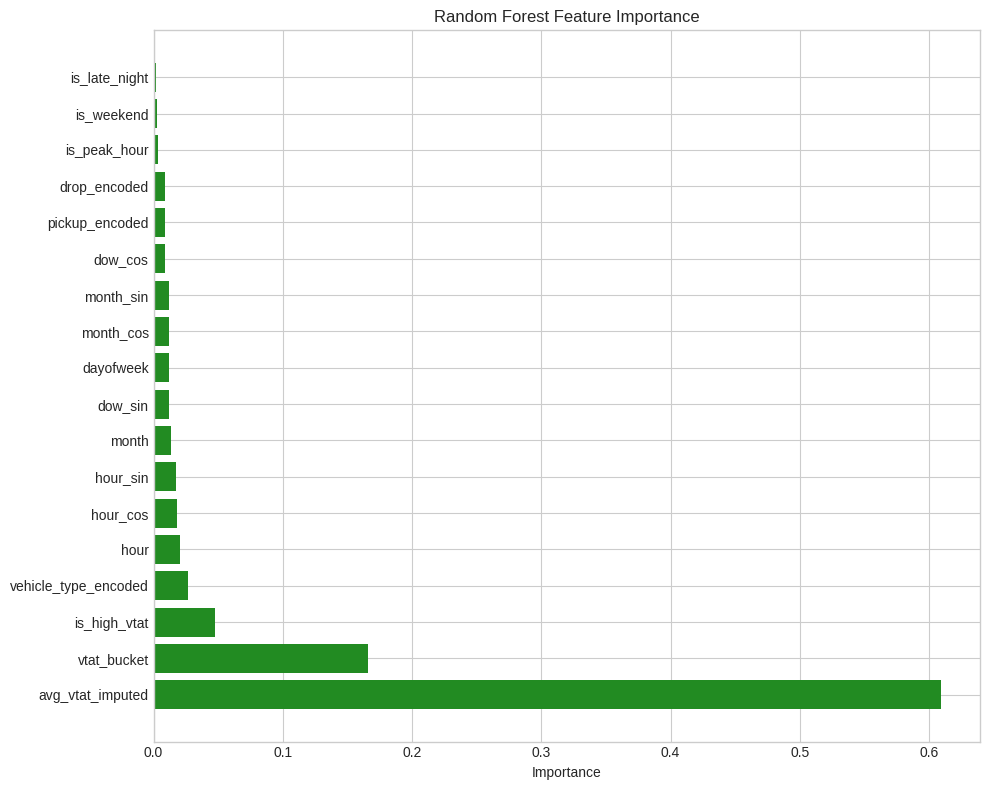

In [8]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance['feature'], feature_importance['importance'], color='forestgreen')
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [9]:
# Save model
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

model_artifacts = {
    'model': model,
    'optimal_threshold': optimal_threshold,
    'feature_names': list(X_train.columns),
    'metrics': {'validation': val_metrics, 'test': test_metrics}
}

with open(os.path.join(models_dir, "random_forest.pkl"), 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f"Model saved to {models_dir}/random_forest.pkl")

Model saved to ../models/random_forest.pkl


In [10]:
# Summary
print("\n" + "="*60)
print("RANDOM FOREST - FINAL SUMMARY")
print("="*60)
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"\nTest Set Performance:")
print(f"  F2-Score:  {test_metrics['f2']:.4f}")
print(f"  Recall:    {test_metrics['recall']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f}")


RANDOM FOREST - FINAL SUMMARY
Optimal Threshold: 0.27

Test Set Performance:
  F2-Score:  0.7352
  Recall:    0.9537
  Precision: 0.3836
